# RankMe evolution of different languages

In [1]:
import pandas as pd
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, os.path.join(REPO_ROOT, "visualization"))
sys.path.insert(0, os.path.join(REPO_ROOT, "geometry_analysis"))

from visualize_shaded_pt_curves import show_training_curves
from fit_rankme import fit_rankme_from_df, plot_fitted_laws, TwoPhaseSharedAC, ThreePhaseSharedAC, ThreePhasePerLangAC

In [2]:
def display_parameter_tables(params_df):
    three_phase = "t_change2" in params_df.columns
    per_language_ac = "beta" not in params_df.columns

    # Shared parameters (identical across all rows)
    if three_phase:
        if per_language_ac:
            shared_cols = ["t_change", "t_change2", "gamma", "lam2", "lam3"]
        else:
            shared_cols = ["t_change", "t_change2", "A", "gamma", "C2", "lam2", "C3", "lam3"]
    else:
        if per_language_ac:
            shared_cols = ["t_change", "gamma", "lam"]
        else:
            shared_cols = ["t_change", "A", "gamma", "C", "lam"]
            
    print("Shared parameters:")
    display(params_df[shared_cols].iloc[[0]].reset_index(drop=True).round(4))

    # Per-language parameters
    if three_phase:
        if per_language_ac:
            per_lang_cols = ["language", "alpha", "A", "C2", "C3", "r2"]
        else:
            per_lang_cols = ["language", "alpha", "beta", "r2"]
    else:
        if per_language_ac:
            per_lang_cols = ["language", "alpha", "A", "C", "r2"]
        else:
            per_lang_cols = ["language", "alpha", "beta", "r2"]
            
    print("Per-language parameters:")
    display(params_df[per_lang_cols].reset_index(drop=True).round(4))

## FuxiTranyu-8B

In [3]:
CSV_PATH = os.path.join(REPO_ROOT, "results", "fuxi_fine_wiki.csv")

fuxi_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(fuxi_df):,} rows from {CSV_PATH}")
fuxi_df.head()

Loaded 48,720 rows from /home/mattia/Documents/GitHub/EPFL/open-project-m2-jpmg/results/fuxi_fine_wiki.csv


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,10B,English,layer_0,last,176.2048,25.4827,1.358558,0.1808,0.2912,0.3473,0.4456,0.5564,0.6930,0.8630,0.9478,0.9855
1,10B,English,layer_1,last,212.2066,22.1531,1.082762,0.2019,0.2897,0.3386,0.4232,0.5179,0.6426,0.8112,0.9109,0.9682
2,10B,English,layer_2,last,218.9397,21.4111,0.986896,0.2043,0.3008,0.3510,0.4333,0.5222,0.6385,0.7964,0.8938,0.9567
3,10B,English,layer_3,last,229.1743,22.3187,0.936015,0.1975,0.3118,0.3620,0.4414,0.5248,0.6335,0.7824,0.8789,0.9470
4,10B,English,layer_4,last,236.1098,23.6482,0.901771,0.1855,0.3225,0.3710,0.4488,0.5275,0.6298,0.7715,0.8669,0.9392


In [4]:
checkpoints = sorted(fuxi_df["checkpoint"].unique(), key=lambda x: int(x.replace("B", "")) if x[0].isdigit() else float("inf"))
languages = sorted(fuxi_df["dataset"].unique())
layers = sorted(fuxi_df["layer"].unique(), key=lambda x: int(x.split("_")[1]))
aggregations = sorted(fuxi_df["aggregation"].unique())
metric_cols = [c for c in fuxi_df.columns if c not in ("checkpoint", "dataset", "layer", "aggregation")]

print(f"Total rows: {len(fuxi_df):,}")
print(f"Checkpoints ({len(checkpoints)}): {checkpoints}")
print(f"Languages ({len(languages)}): {languages}")
print(f"Layers ({len(layers)}): {[layer.split('_')[1] for layer in layers]}")
print(f"Aggregations ({len(aggregations)}): {aggregations}")
print(f"Metrics ({len(metric_cols)}): {metric_cols}")

Total rows: 48,720
Checkpoints (58): ['10B', '21B', '31B', '42B', '52B', '63B', '73B', '84B', '94B', '105B', '115B', '126B', '136B', '147B', '157B', '168B', '178B', '189B', '199B', '210B', '220B', '231B', '241B', '252B', '262B', '273B', '283B', '294B', '304B', '315B', '325B', '334B', '342B', '352B', '363B', '373B', '384B', '394B', '405B', '415B', '426B', '436B', '447B', '457B', '468B', '478B', '489B', '499B', '510B', '520B', '531B', '541B', '552B', '562B', '573B', '583B', '593B', 'main']
Languages (14): ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Layers (30): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']
Aggregations (2): ['last', 'mean']
Metrics (12): ['rankme', 'pr', 'alpha_req', 'top_1_var', 'top_5_var', 'top_10_var', 'top_25_var', 'top_50_var', 'to

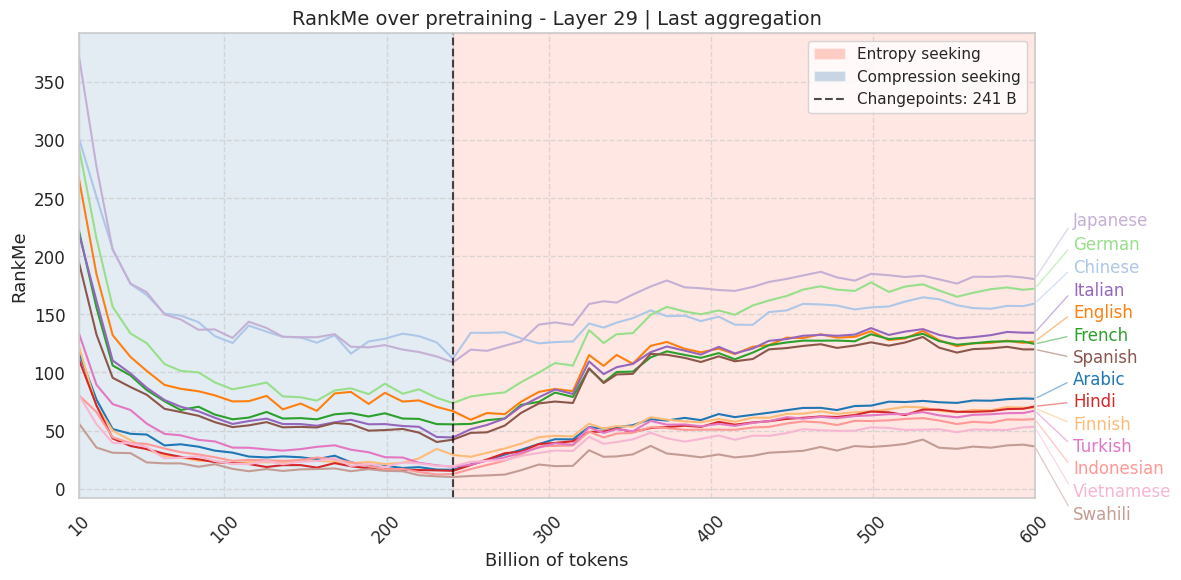

In [5]:
show_training_curves(fuxi_df, metrics=["rankme"], layers=["layer_29"], aggregations=["last"], main_value=600, smoothing=1)

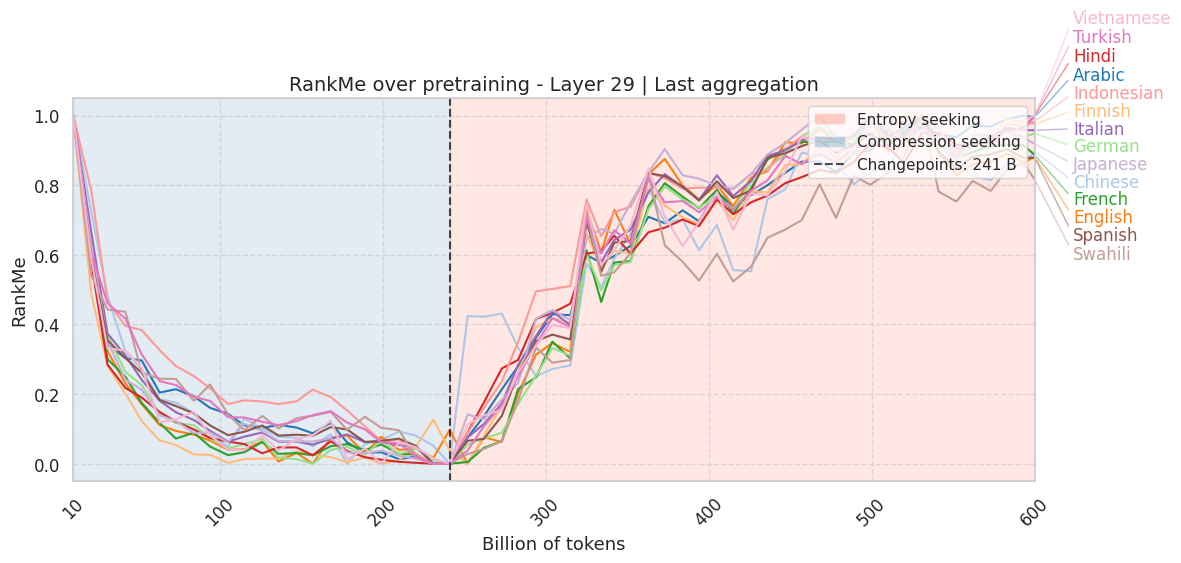

In [6]:
show_training_curves(fuxi_df, metrics=["rankme"], layers=["layer_29"], aggregations=["last"], smoothing=1, main_value=600, normalize="per-segment")

In [7]:
fuxi_model = TwoPhaseSharedAC()
fuxi_params_df = fit_rankme_from_df(fuxi_df, layer="layer_29", aggregation="last", model=fuxi_model, changepoints=[241])

In [8]:
display_parameter_tables(fuxi_params_df)

Shared parameters:


,t_change,A,gamma,C,lam
0,241.0,1.056592e+11,0.7385,7.559091e+09,115.7193


Per-language parameters:


,language,alpha,beta,r2
0,Arabic,8.1093,0.0,0.9420
1,Chinese,101.6599,0.0,0.6887
2,English,42.1713,0.0,0.9291
3,Finnish,9.5926,0.0,0.9185
4,French,33.2477,0.0,0.9607
5,German,46.9078,0.0,0.9687
6,Hindi,4.5468,0.0,0.9401
7,Indonesian,10.9814,0.0,0.8894
8,Italian,27.2817,0.0,0.9563
9,Japanese,86.6998,0.0,0.8915


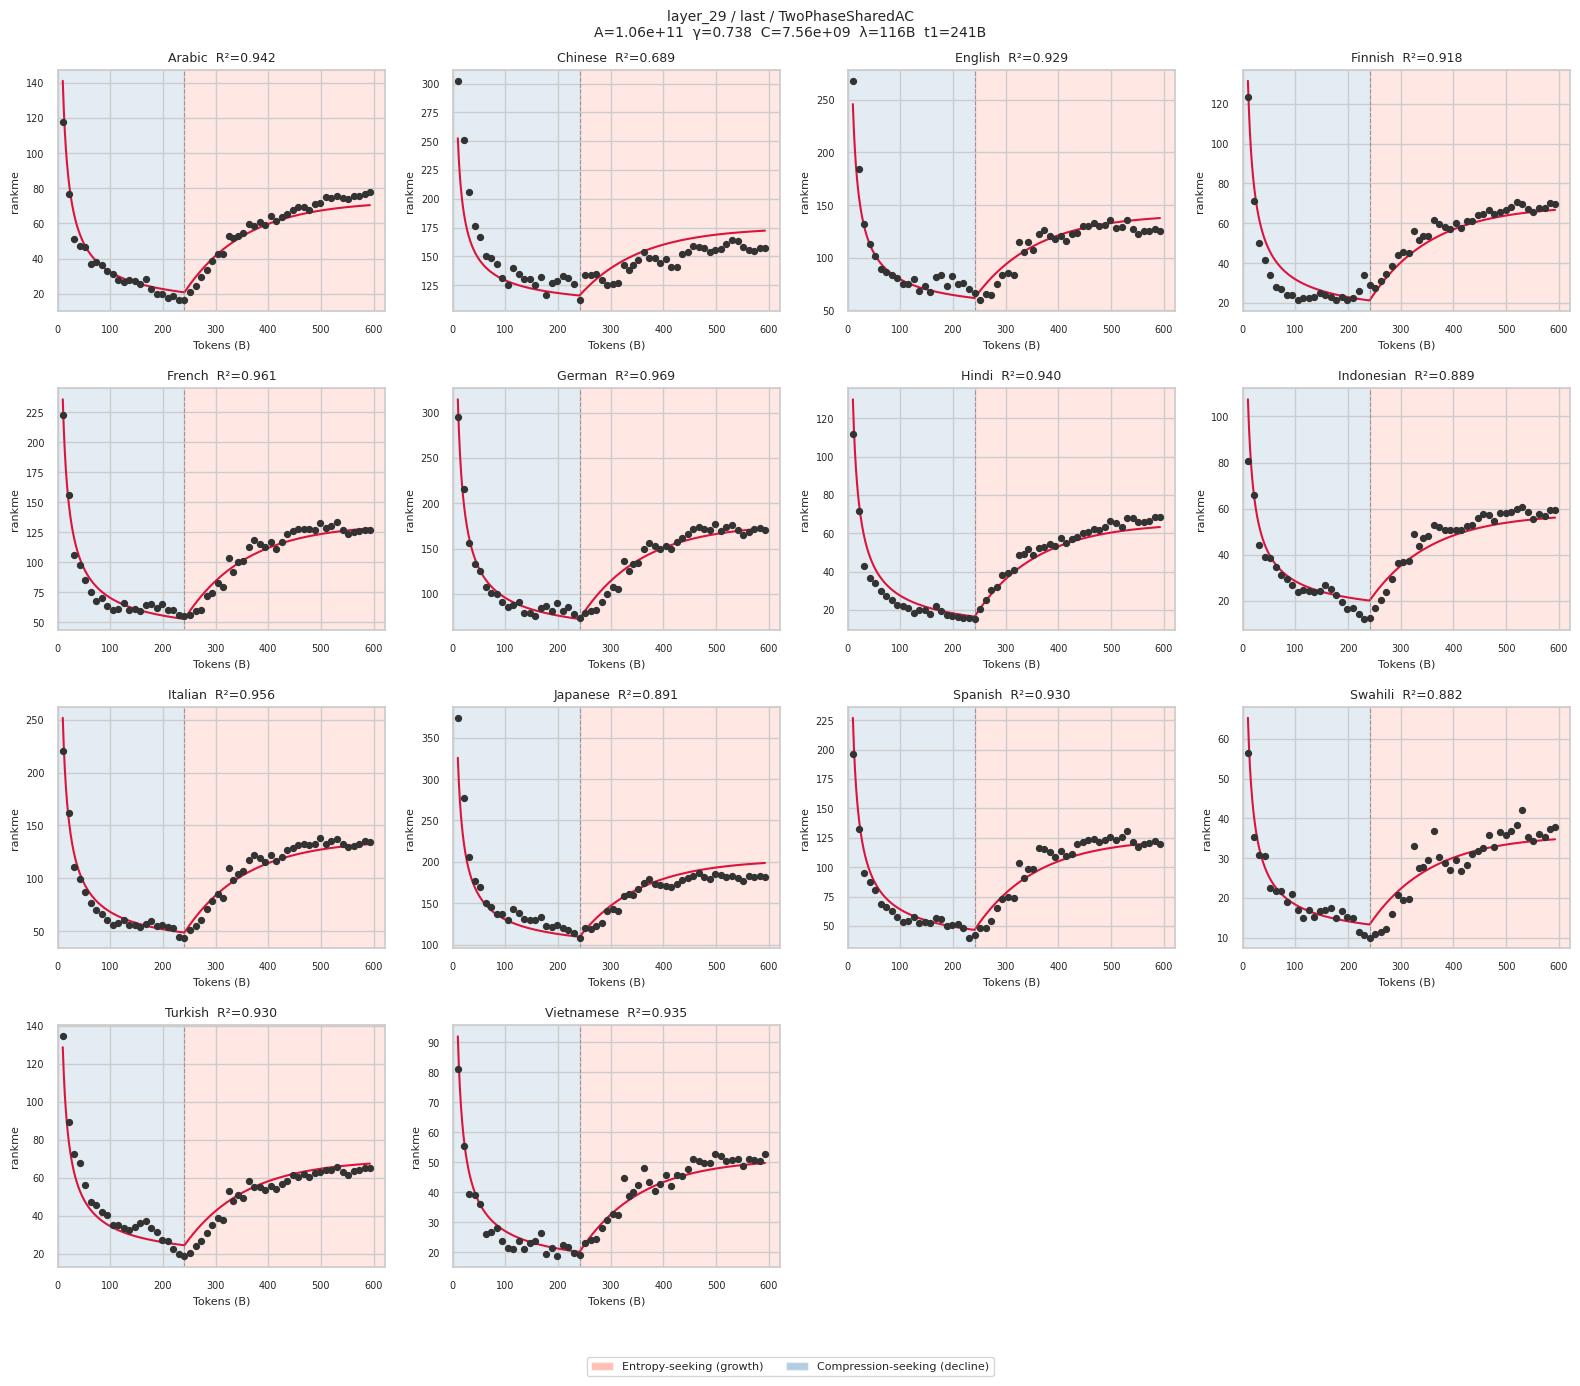

In [9]:
plot_fitted_laws(fuxi_params_df, fuxi_df, model=fuxi_model)

## Apertus-8B-2509

In [10]:
CSV_PATH = os.path.join(REPO_ROOT, "results", "apertus_fine_wiki.csv")

apertus_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(apertus_df):,} rows from {CSV_PATH}")
apertus_df.head()

Loaded 40,320 rows from /home/mattia/Documents/GitHub/EPFL/open-project-m2-jpmg/results/apertus_fine_wiki.csv


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,step50000-tokens210B,English,layer_0,last,5.8682,1.5762,1.188366,0.7962,0.8309,0.8427,0.8605,0.8777,0.8991,0.9328,0.9609,0.9854
1,step50000-tokens210B,English,layer_1,last,7.5185,1.6438,0.806348,0.7798,0.8064,0.8165,0.8329,0.8488,0.8688,0.9022,0.9330,0.9657
2,step50000-tokens210B,English,layer_2,last,9.9573,2.1356,0.731912,0.6738,0.8088,0.8189,0.8340,0.8486,0.8668,0.8981,0.9279,0.9607
3,step50000-tokens210B,English,layer_3,last,20.5941,2.7820,0.691209,0.5892,0.7239,0.7403,0.7627,0.7829,0.8080,0.8511,0.8927,0.9396
4,step50000-tokens210B,English,layer_4,last,48.5817,4.2219,0.668665,0.4745,0.6192,0.6430,0.6747,0.7025,0.7362,0.7943,0.8504,0.9142


In [11]:
checkpoints = sorted(apertus_df["checkpoint"].unique(), key=lambda x: int(x.replace("B", "")) if x[0].isdigit() else float("inf"))
languages = sorted(apertus_df["dataset"].unique())
layers = sorted(apertus_df["layer"].unique(), key=lambda x: int(x.split("_")[1]))
aggregations = sorted(apertus_df["aggregation"].unique())
metric_cols = [c for c in apertus_df.columns if c not in ("checkpoint", "dataset", "layer", "aggregation")]

print(f"Total rows: {len(apertus_df):,}")
print(f"Checkpoints ({len(checkpoints)}): {checkpoints}")
print(f"Languages ({len(languages)}): {languages}")
print(f"Layers ({len(layers)}): {[layer.split('_')[1] for layer in layers]}")
print(f"Aggregations ({len(aggregations)}): {aggregations}")
print(f"Metrics ({len(metric_cols)}): {metric_cols}")

Total rows: 40,320
Checkpoints (45): ['step50000-tokens210B', 'step100000-tokens420B', 'step150000-tokens630B', 'step200000-tokens840B', 'step250000-tokens1050B', 'step300000-tokens1260B', 'step350000-tokens1470B', 'step400000-tokens1680B', 'step450000-tokens1890B', 'step500000-tokens2100B', 'step550000-tokens2310B', 'step600000-tokens2520B', 'step650000-tokens2730B', 'step700000-tokens2940B', 'step750000-tokens3150B', 'step800000-tokens3360B', 'step850000-tokens3570B', 'step900000-tokens3780B', 'step950000-tokens3990B', 'step1000000-tokens4200B', 'step1194000-tokens5014B', 'step1432000-tokens6014B', 'step1670000-tokens7014B', 'step1678000-tokens7047B', 'step1700000-tokens7232B', 'step1750000-tokens7652B', 'step1800000-tokens8072B', 'step1850000-tokens8492B', 'step1900000-tokens8912B', 'step1950000-tokens9332B', 'step2000000-tokens9752B', 'step2050000-tokens10172B', 'step2100000-tokens10592B', 'step2150000-tokens11012B', 'step2200000-tokens11432B', 'step2250000-tokens11852B', 'step2300

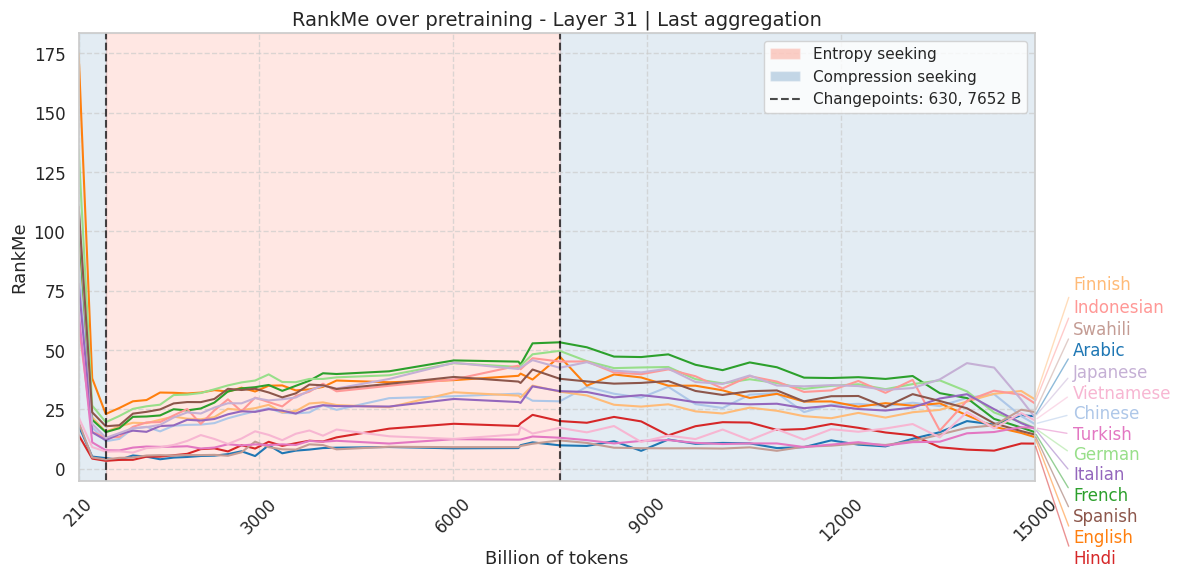

In [12]:
show_training_curves(apertus_df, metrics=["rankme"], layers=["layer_31"], aggregations=["last"], smoothing=0.2)

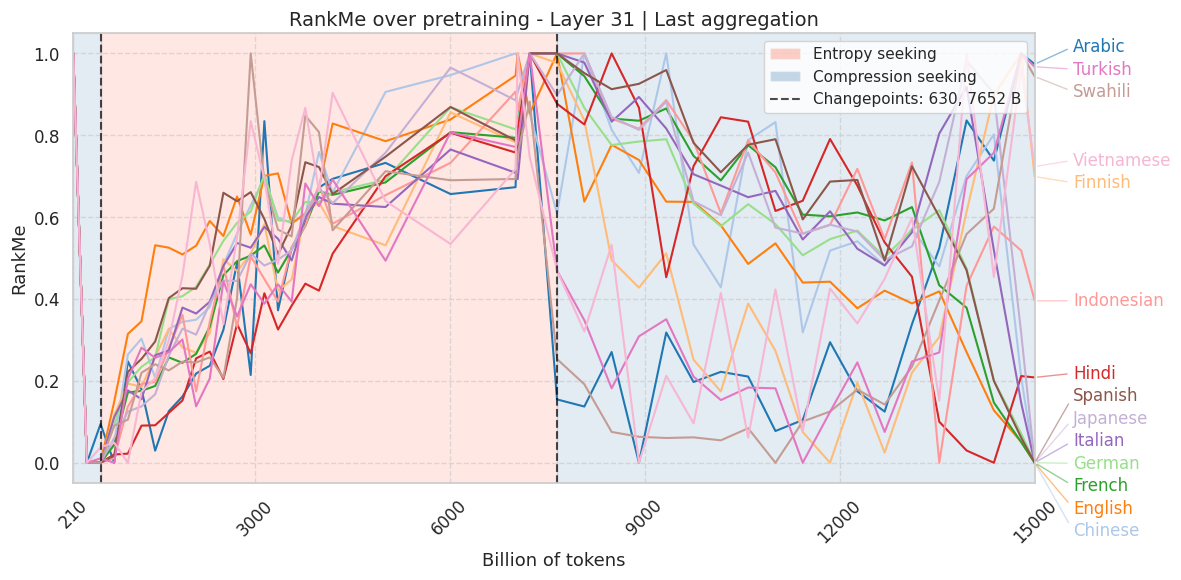

In [13]:
show_training_curves(apertus_df, metrics=["rankme"], layers=["layer_31"], aggregations=["last"], smoothing=0.20, normalize="per-segment")

In [14]:
apertus_model = ThreePhaseSharedAC()
apertus_params_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_model, changepoints=[630, 7652], t_scale=1000)

In [15]:
display_parameter_tables(apertus_params_df)

Shared parameters:


,t_change,t_change2,A,gamma,C2,lam2,C3,lam3
0,630.0,7652.0,1.140809e+19,3.7341,6.901058e+09,4261.1576,-5.810193e+09,7348.0


Per-language parameters:


,language,alpha,beta,r2
0,Arabic,8.0242,0.0,0.1009
1,Chinese,14.2913,0.0,0.9141
2,English,10.5196,0.0,0.9009
3,Finnish,13.8750,0.0,0.9118
4,French,21.1465,0.0,0.8300
5,German,18.4962,0.0,0.9600
6,Hindi,9.9916,0.0,0.1665
7,Indonesian,23.1630,0.0,0.5549
8,Italian,15.2667,0.0,0.9195
9,Japanese,18.3625,0.0,0.8799


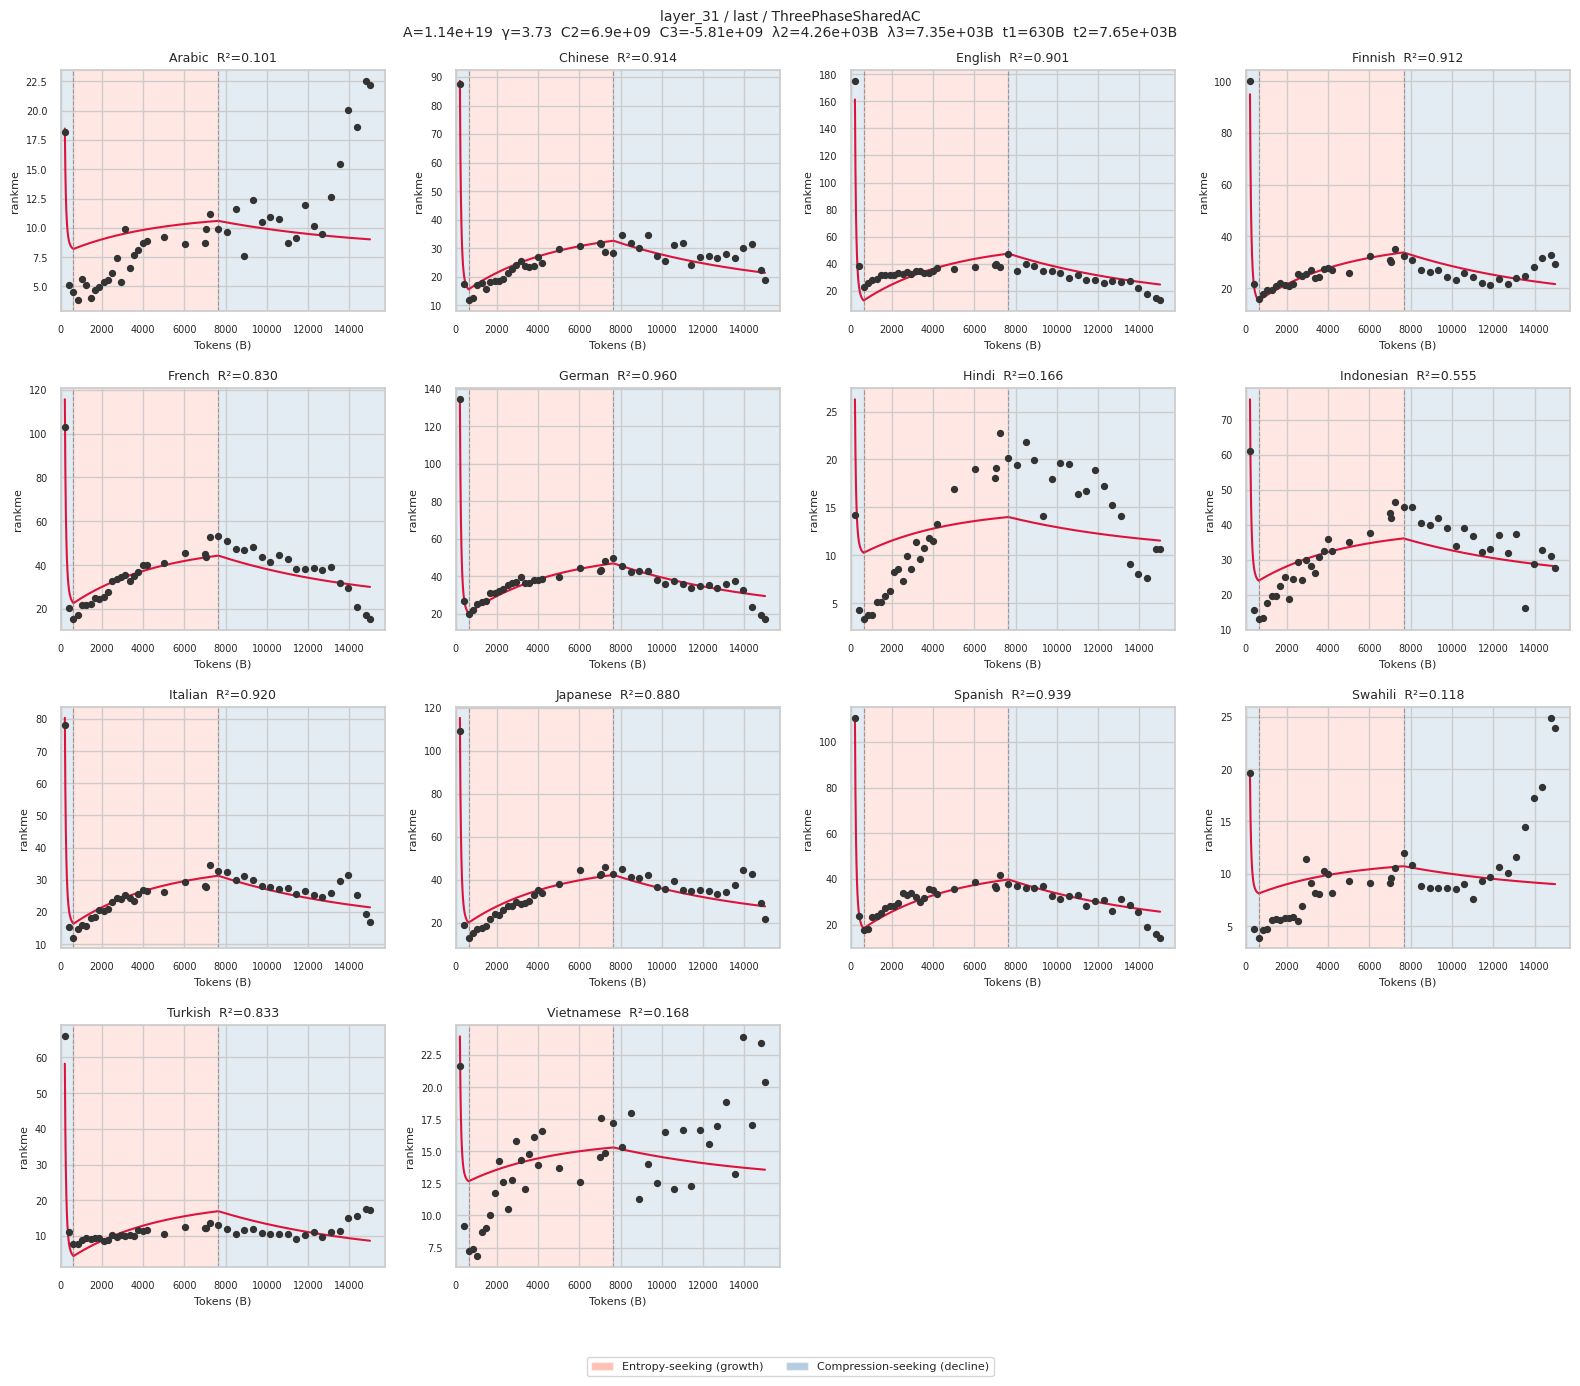

In [16]:
plot_fitted_laws(apertus_params_df, apertus_df, model=apertus_model)

In [17]:
apertus_model_per_lang = ThreePhasePerLangAC()
apertus_params_per_language_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_model_per_lang, changepoints=[630, 7652], t_scale=1000)

In [18]:
display_parameter_tables(apertus_params_per_language_df)

Shared parameters:


,t_change,t_change2,gamma,lam2,lam3
0,630.0,7652.0,4.3128,4533.1809,7348.0


Per-language parameters:


,language,alpha,A,C2,C3,r2
0,Arabic,4.4399,1.421647e+11,5.4913,10.5004,0.7314
1,Chinese,12.8154,7.747301e+11,24.4855,-17.5342,0.9541
2,English,26.2348,1.543162e+12,19.2071,-39.2287,0.9866
3,Finnish,17.8127,8.525696e+11,15.5956,-12.7753,0.9413
4,French,14.6605,9.167377e+11,47.3798,-52.7775,0.9346
5,German,22.1424,1.162818e+12,32.3155,-42.3785,0.9675
6,Hindi,1.0778,1.377272e+11,24.6324,-21.0929,0.8608
7,Indonesian,12.5830,5.034689e+11,39.8866,-35.6298,0.8977
8,Italian,13.5233,6.666055e+11,23.5237,-20.1460,0.9488
9,Japanese,13.1119,9.967974e+11,39.2419,-29.1187,0.9523


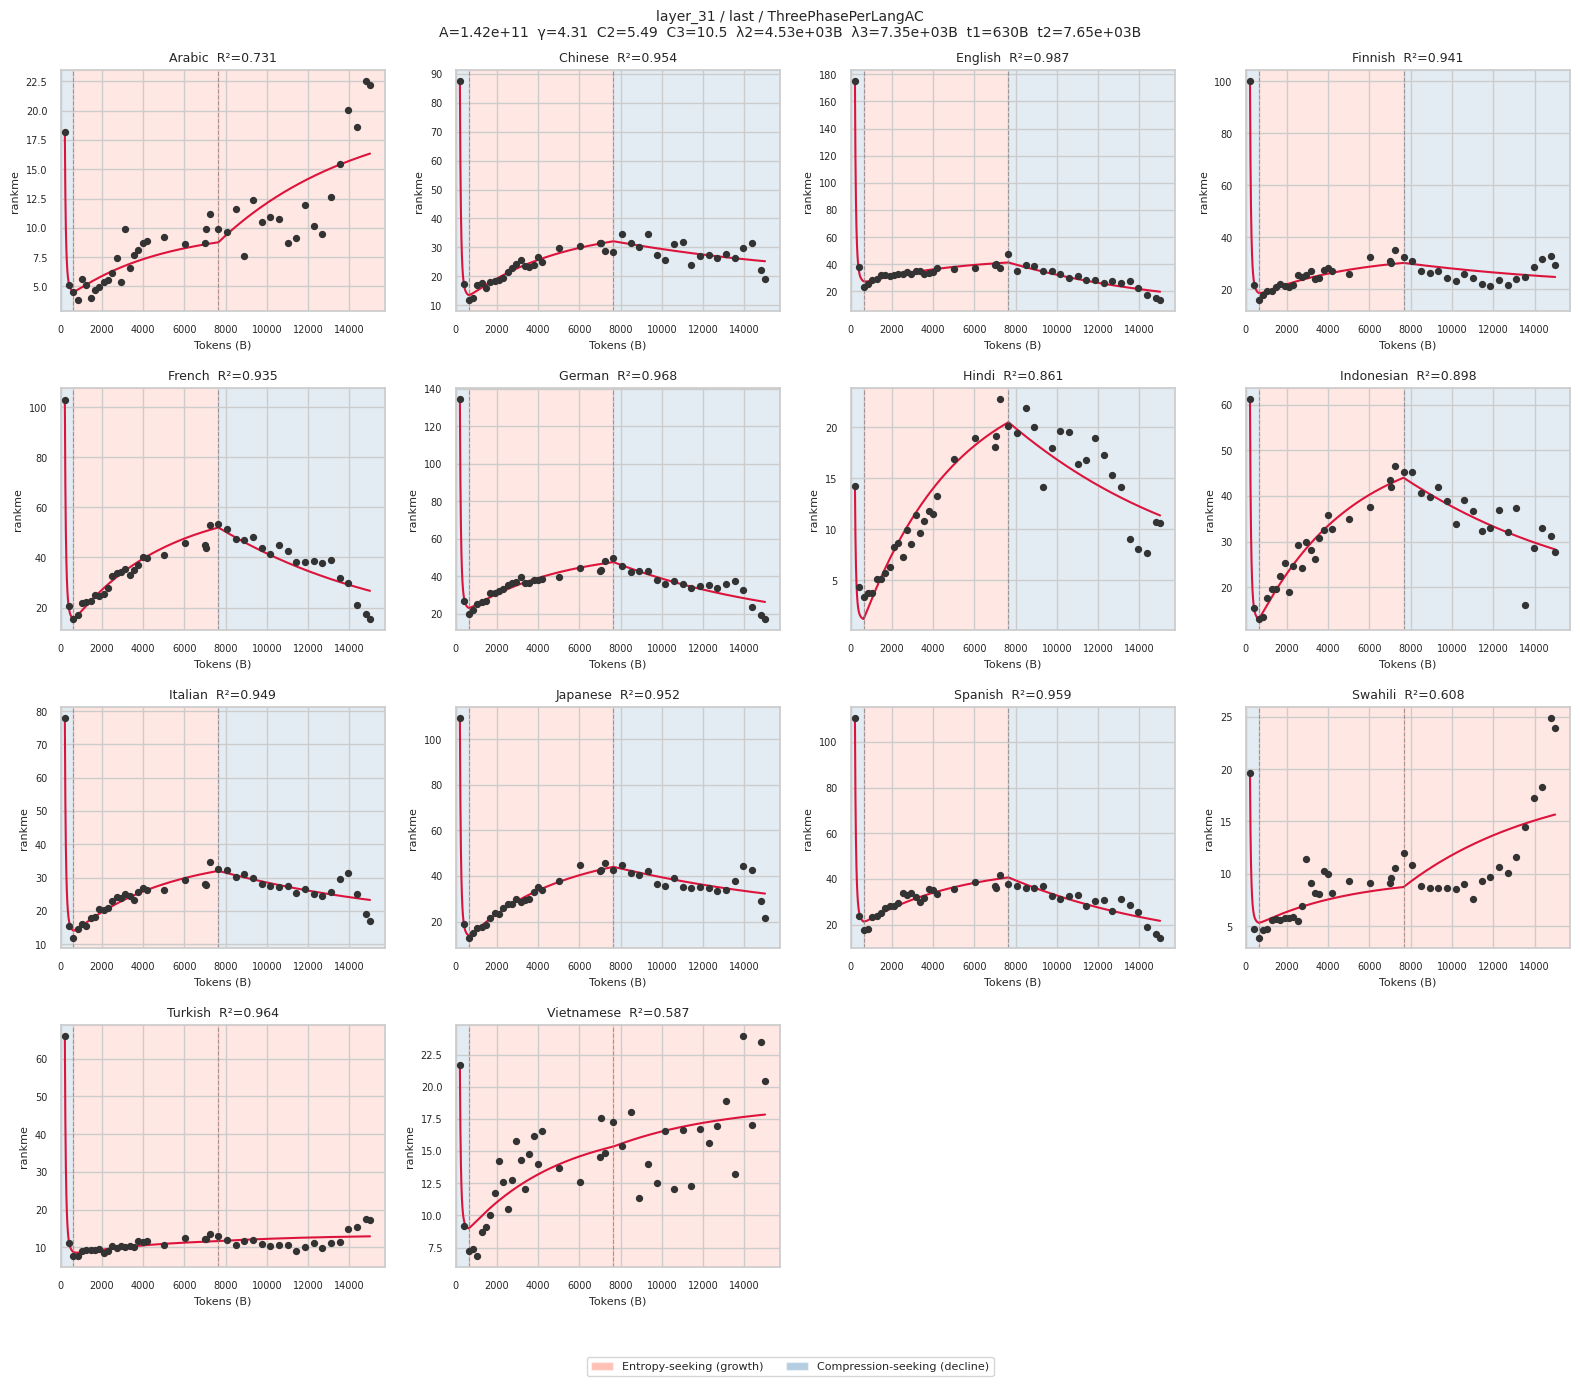

In [19]:
plot_fitted_laws(apertus_params_per_language_df, apertus_df, model=apertus_model_per_lang)